# Bank Customer Churn Prediction — Neural Network

**Goal:** given a bank customer, build a neural-network classifier that predicts whether they will **leave (churn)** or **stay**.

**Dataset:** 10,000 customers with 14 columns (CustomerId, CreditScore, Geography, Gender, Age, Tenure, Balance, ...). The target is `Exited` (1 = left, 0 = stayed).

This is a **binary classification** problem, solved with a feed-forward neural network in Keras / TensorFlow.

## Section 0 — Setup

In [1]:
import os, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import warnings; warnings.filterwarnings('ignore')

# Lock all random seeds so the model trains the same way every run (reproducible results).
SEED = 42
def set_seed(s=SEED):
    os.environ['PYTHONHASHSEED'] = str(s)
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
set_seed()

I0000 00:00:1781565246.393424     529 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781565270.787500     529 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Section 1 — Read the data set
Load the CSV and take a first look: shape, column types, and the balance of the target.

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print('Rows, Columns:', df.shape)
df.info()

Rows, Columns: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


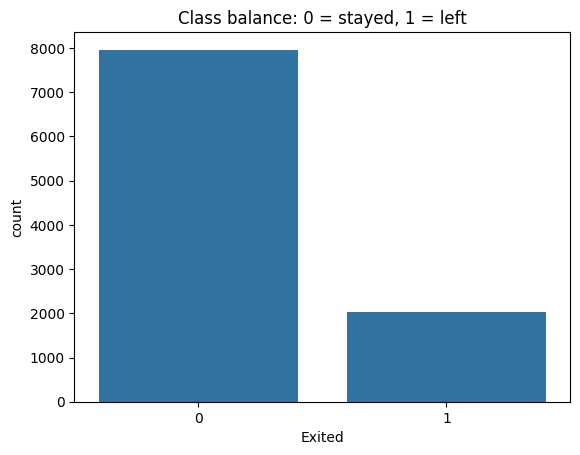

In [4]:
# How many customers churned (1) vs stayed (0)?
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True).round(3))
sns.countplot(x='Exited', data=df)
plt.title('Class balance: 0 = stayed, 1 = left'); plt.show()

**Class imbalance:** about **80%** of customers stayed and only **~20%** left. This matters because plain accuracy can be misleading — a model that predicts "nobody leaves" is already ~80% accurate while catching zero churners. So we will also track **recall**.

## Section 2 — Drop columns that are unique per customer (IDs)
`RowNumber`, `CustomerId` and `Surname` are identifiers. They carry no general pattern, so we remove them to keep the model focused on real signal.

In [5]:
df.drop(labels=['RowNumber','CustomerId','Surname'], axis=1, inplace=True)
print('Shape after dropping IDs:', df.shape)
df.head(2)

Shape after dropping IDs: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


## Section 3 — Separate features (X) and target (y), then encode categories
`X` holds the inputs, `y` holds the answer (`Exited`). Two columns are text — `Geography` and `Gender` — and a neural network reads only numbers, so we convert them with **one-hot encoding** (`get_dummies`): each category becomes its own 0/1 column.

In [6]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [7]:
# Which feature columns are text and therefore need encoding?
print('Text columns to encode:', [c for c in X.columns if X[c].dtype == 'object'])

Text columns to encode:

 []


In [8]:
X = pd.get_dummies(X, columns=['Geography', 'Gender'])
print('Feature count after encoding:', X.shape[1])
print(list(X.columns))
X.head(2)

Feature count after encoding: 13
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False


After encoding we have **13 features** — that is the number the input layer must expect.

## Section 4 — Split into training and test sets
We hold back 20% as an unseen test set — the honest exam the model never sees during training. `stratify=y` keeps the 80/20 ratio in both halves so the split is fair.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (8000, 13)  Test: (2000, 13)


## Section 5 — Normalize (scale) the data
Features live on very different scales (Balance in the tens of thousands, Age in the tens). **StandardScaler** re-centres each feature so the large numbers don't dominate. We learn the scaling on the training data only and apply it to the test data, so no information leaks from the exam into the study.

In [10]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)   # learn + apply on train
X_test  = sc.transform(X_test)        # apply the same scaling on test

## Section 6 — Build and train the neural network
A small feed-forward network: an input layer expecting 13 features, two hidden layers with **ReLU**, and a single output neuron with **sigmoid**, which returns a probability between 0 and 1 — exactly what binary classification needs. We compile with the **adam** optimizer and **binary_crossentropy** loss.

In [11]:
set_seed()   # reproducible weights
classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),   # 13 features
    tf.keras.layers.Dense(7, activation='relu'),        # hidden layer 1
    tf.keras.layers.Dense(6, activation='relu'),        # hidden layer 2
    tf.keras.layers.Dense(1, activation='sigmoid')      # output: probability of churn
])

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            98 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153 (612.00 B)

 Trainable params: 153 (612.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# batch_size = rows per weight update; epochs = passes over the data
history = classifier.fit(X_train, y_train, batch_size=30, epochs=30, verbose=1)

Epoch 1/30


  1/267 ━━━━━━━━━━━━━━━━━━━━ 7:24 2s/step - accuracy: 0.4000 - loss: 0.8618

 29/267 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4336 - loss: 0.7980 

 60/267 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4647 - loss: 0.7733

 93/267 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4964 - loss: 0.7508

...

132/267 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8596 - loss: 0.3545

167/267 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8584 - loss: 0.3547

201/267 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8578 - loss: 0.3547

235/267 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8573 - loss: 0.3549

267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8509 - loss: 0.3573


## Section 7 — Predict using 0.5 as the threshold
The network outputs a probability of leaving. We call anything above **0.5** a predicted churn (1).

In [13]:
y_prob = classifier.predict(X_test)        # probabilities
y_pred = (y_prob > 0.5).astype(int)        # turn into 0/1 decisions
y_pred[:10].ravel()

 1/63 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step

55/63 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

## Section 8 — Accuracy, confusion matrix, and the full metric report
Because of the 80/20 imbalance, accuracy alone isn't enough. We also report **recall** (of the customers who really left, how many we caught) and **precision** (of those we flagged, how many truly left).

[[1548   45]
 [ 236  171]]


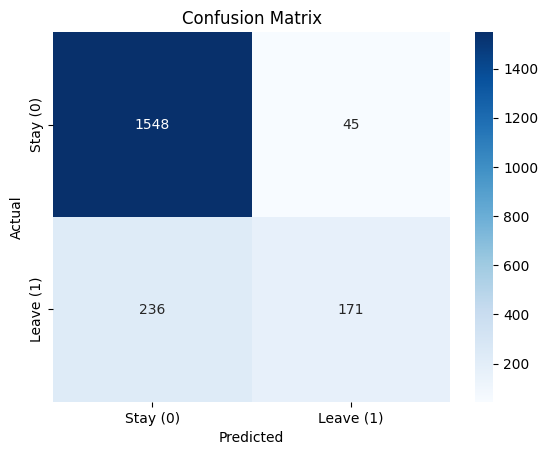

In [14]:
confMatrix = confusion_matrix(y_test, y_pred)
print(confMatrix)

sns.heatmap(confMatrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay (0)','Leave (1)'], yticklabels=['Stay (0)','Leave (1)'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()

In [15]:
score = classifier.evaluate(X_test, y_test, verbose=0)
print('Test loss:', round(score[0],4), '| Test accuracy:', round(score[1],4))

Test loss: 0.3579 | Test accuracy: 0.8595


In [16]:
print(classification_report(y_test, y_pred, target_names=['Stay (0)','Leave (1)']))

              precision    recall  f1-score   support

    Stay (0)       0.87      0.97      0.92      1593
   Leave (1)       0.79      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



In [17]:
def confusion_metrics(cm):
    # Rows = actual, Columns = predicted.
    TN, FP = cm[0][0], cm[0][1]
    FN, TP = cm[1][0], cm[1][1]
    print('True Positives :', TP, ' (churners correctly caught)')
    print('True Negatives :', TN, ' (stayers correctly kept)')
    print('False Positives:', FP, ' (false alarms)')
    print('False Negatives:', FN, ' (missed churners)')
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN)              # recall
    specificity = TN / (TN + FP)
    precision   = TP / (TP + FP)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
    print('-'*50)
    print(f'Accuracy   : {accuracy:.2f}')
    print(f'Recall     : {sensitivity:.2f}   (a.k.a. sensitivity)')
    print(f'Specificity: {specificity:.2f}')
    print(f'Precision  : {precision:.2f}')
    print(f'F1 Score   : {f1:.2f}')

confusion_metrics(confMatrix)

True Positives : 171  (churners correctly caught)
True Negatives : 1548  (stayers correctly kept)
False Positives: 45  (false alarms)
False Negatives: 236  (missed churners)
--------------------------------------------------
Accuracy   : 0.86
Recall     : 0.42   (a.k.a. sensitivity)
Specificity: 0.97
Precision  : 0.79
F1 Score   : 0.55


## Section 9 — Tune the network with K-Fold cross-validation
Cross-validation re-tests several parameter combinations on different slices of the training data and keeps the best, so the chosen settings aren't a fluke of one split. We use **scikeras** to plug the Keras model into scikit-learn's `GridSearchCV`.

*(The grid is kept small so it runs quickly; widen `param_grid` to search more.)*

In [18]:
from scikeras.wrappers import KerasClassifier

In [19]:
def build_classifier(optimizer='adam'):
    set_seed()
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(7, activation='relu'),
        tf.keras.layers.Dense(6, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [20]:
classifier_cv = KerasClassifier(model=build_classifier, optimizer='adam', verbose=0)

param_grid = {'batch_size':[25,32], 'epochs':[20], 'optimizer':['adam','rmsprop']}
grid = GridSearchCV(estimator=classifier_cv, param_grid=param_grid, scoring='accuracy', cv=3)
grid = grid.fit(X_train, y_train)
print('Best parameters:', grid.best_params_)
print('Best CV accuracy:', round(grid.best_score_, 4))

Best parameters: {'batch_size': 25, 'epochs': 20, 'optimizer': 'adam'}
Best CV accuracy: 0.8339


## Conclusions
- The network reaches roughly **85–86%** accuracy, but on **~80/20** data accuracy is the wrong headline. The number that matters for a churn programme is **recall** — how many real leavers we catch — because a missed churner is a customer lost in silence.
- Cross-validation confirms the result is stable and points to a good batch size and optimizer.
- **Next steps:** handle the class imbalance (class weights or resampling), look at which features drive a churn prediction (explainability), and compare performance across groups such as Geography and Gender.